# Task 2: Vision Task - Assignment-Aligned Emotion Recognition Notebook

**Dataset:** Facial expression classification  
**Goal:** Classify facial expressions into emotion classes with (A) CNNs built from scratch and (B) a fine-tuned pre-trained model inspired by the uploaded `facial-expression-based-emotion-recognition` notebook.

This notebook is organized to match the assignment tasks:
- dataset understanding, cleaning, visualization, and preprocessing
- baseline CNN from scratch
- deeper CNN with regularization
- optimizer comparison and ablation study
- transfer learning and fine-tuning
- final comparative analysis

### Code explanation
This cell checks whether the notebook is running in Google Colab. When Colab is available, it mounts Google Drive so dataset files and saved model outputs can be accessed; otherwise, it safely continues without Drive access.


In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print("Not running inside Google Colab. Skipping Drive mount.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Code explanation
This cell imports the libraries used for file handling, numerical processing, plotting, image loading, TensorFlow/Keras modeling, and evaluation metrics. It also installs TensorFlow if needed, sets random seeds for reproducibility, and prints the TensorFlow and GPU environment details.


In [ ]:
import os
import random
import time
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

!pip install tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,
    Rescaling, GlobalAveragePooling2D
)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_recall_fscore_support
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Code explanation
This cell locates the facial-expression dataset. It checks possible extracted folders first, extracts the dataset ZIP if necessary, then stores the train, validation, and test folder paths for the rest of the notebook.


In [ ]:
from pathlib import Path

ZIP_CANDIDATES = [
    "/content/drive/MyDrive/AL ML/Assignment/facial expression classification.zip",
    "/content/drive/MyDrive/facial expression classification.zip",
]

EXTRACT_CANDIDATES = [
    "/content/facial_expressions_dataset/facial expression classification",
    "/content/facial expression classification",
    "/kaggle/input/facial-expression-classification/facial expression classification",
]

DEFAULT_EXTRACT_PARENT = "/content/facial_expressions_dataset"

def find_existing_data_root(extract_candidates):
    for candidate in extract_candidates:
        candidate = Path(candidate)
        if candidate.exists() and (candidate / "train").exists():
            return str(candidate)
    return None

DATA_ROOT = find_existing_data_root(EXTRACT_CANDIDATES)

if DATA_ROOT is None:
    zip_path = next((p for p in ZIP_CANDIDATES if os.path.exists(p)), None)
    if zip_path is None:
        raise FileNotFoundError(
            "Dataset not found. Update ZIP_CANDIDATES or EXTRACT_CANDIDATES so the notebook can find your dataset."
        )

    os.makedirs(DEFAULT_EXTRACT_PARENT, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(DEFAULT_EXTRACT_PARENT)

    DATA_ROOT = find_existing_data_root([
        str(Path(DEFAULT_EXTRACT_PARENT) / "facial expression classification"),
        DEFAULT_EXTRACT_PARENT
    ])

    if DATA_ROOT is None:
        raise FileNotFoundError("Extraction finished but train/validation/test folders were not found.")

print("Resolved dataset root:", DATA_ROOT)

train_data_dir = os.path.join(DATA_ROOT, "train")
validation_data_dir = os.path.join(DATA_ROOT, "validation")
test_data_dir = os.path.join(DATA_ROOT, "test")

for path in [train_data_dir, validation_data_dir, test_data_dir]:
    print(path, "exists:", os.path.exists(path))


Resolved dataset root: /content/facial_expressions_dataset/facial expression classification
/content/facial_expressions_dataset/facial expression classification/train exists: True
/content/facial_expressions_dataset/facial expression classification/validation exists: True
/content/facial_expressions_dataset/facial expression classification/test exists: True


## Dataset understanding and cleaning

The dataset contains facial images grouped by emotion class. There are a total of 35887 images in the dataset before cleaing.  
classes in this dataset are: `angry`, `disgust`, `fear`, `happy`, `neutral`, `sad`, and `surprise`, with 4946, 540, 5114, 8982, 6782, 6070 and 3995 datas respectively after clearing the data.

This notebook uses the provided split:
- **train** for model fitting
- **validation** for tuning and early stopping
- **test** for final evaluation only

This is a good assignment-aligned split because the validation data stays separate from the test data, so model-selection decisions do not leak test information.

Preprocessing choices used later:
- resize images to **48×48 grayscale** for CNNs built from scratch
- normalize pixel values with `Rescaling(1./255)`
- apply mild data augmentation to improve generalization
- convert grayscale images to **224×224 RGB** for transfer learning so the pre-trained backbone can use ImageNet weights

### Code explanation
This cell defines helper functions for counting image files, checking image validity, and removing corrupted images. It reports image totals before and after cleaning so the dataset quality can be verified.


In [ ]:
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

def count_images_by_class(data_dir):
    counts = {}
    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(IMAGE_EXTENSIONS)
            ])
    return counts

def count_total_images(root_dir):
    total = 0
    for split in ["train", "validation", "test"]:
        split_dir = os.path.join(root_dir, split)
        if os.path.exists(split_dir):
            total += sum(count_images_by_class(split_dir).values())
    return total

def find_bad_images(root_dir):
    bad_files = []
    for dirpath, _, filenames in os.walk(root_dir):
        for fname in filenames:
            if fname.lower().endswith(IMAGE_EXTENSIONS):
                fpath = os.path.join(dirpath, fname)
                try:
                    with Image.open(fpath) as img:
                        img.verify()
                except Exception as e:
                    bad_files.append((fpath, str(e)))
    return pd.DataFrame(bad_files, columns=["file_path", "error"])

def remove_bad_images(bad_df):
    removed = 0
    for path in bad_df["file_path"]:
        if os.path.exists(path):
            os.remove(path)
            removed += 1
    return removed

print("Total images before cleaning:", count_total_images(DATA_ROOT))

bad_train = find_bad_images(train_data_dir)
bad_val = find_bad_images(validation_data_dir)
bad_test = find_bad_images(test_data_dir)

print("Bad train images:", len(bad_train))
print("Bad validation images:", len(bad_val))
print("Bad test images:", len(bad_test))

removed = remove_bad_images(bad_train) + remove_bad_images(bad_val) + remove_bad_images(bad_test)
print("Removed corrupted images:", removed)
print("Total images after cleaning:", count_total_images(DATA_ROOT))


Total images before cleaning: 35887
Bad train images: 49
Bad validation images: 0
Bad test images: 0
Removed corrupted images: 49
Total images after cleaning: 35838


### Code explanation
This cell counts the number of images in each emotion class for the train, validation, and test splits. It displays the counts in a table and plots the training-set class distribution to reveal class imbalance.


,train,validation,test
angry,3686,960,300
disgust,329,111,100
fear,3796,1018,300
happy,6857,1825,300
neutral,4675,1216,300
sad,4631,1139,300
surprise,2898,797,300
TOTAL,26872,7066,1900


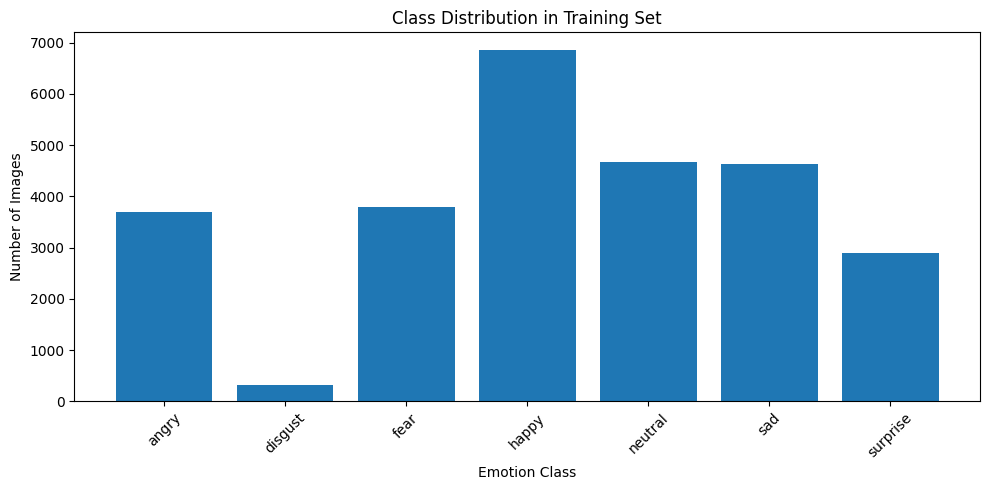

In [ ]:
train_class_counts = count_images_by_class(train_data_dir)
val_class_counts = count_images_by_class(validation_data_dir)
test_class_counts = count_images_by_class(test_data_dir)

distribution_df = pd.DataFrame({
    "train": train_class_counts,
    "validation": val_class_counts,
    "test": test_class_counts
}).fillna(0).astype(int)

distribution_df.loc["TOTAL"] = distribution_df.sum(axis=0)
display(distribution_df)

plt.figure(figsize=(10, 5))
plt.bar(train_class_counts.keys(), train_class_counts.values())
plt.title("Class Distribution in Training Set")
plt.xlabel("Emotion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Code explanation
This cell randomly selects one image from each training class and displays the samples in a grid. The visualization helps confirm that images are loaded correctly and that each class folder contains relevant facial-expression examples.


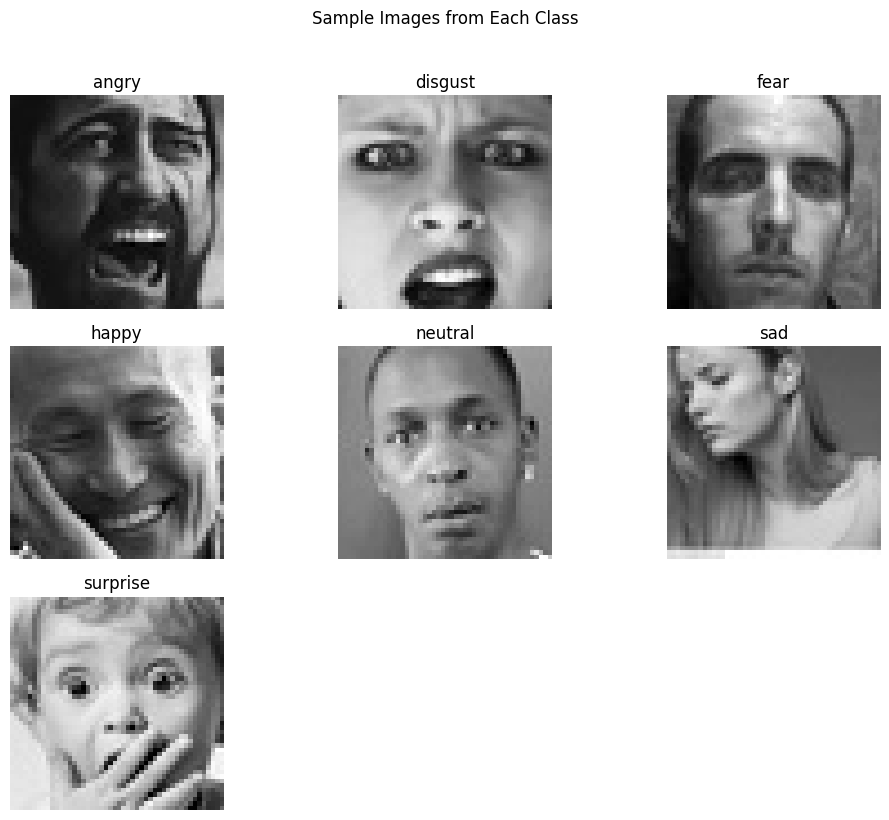

In [ ]:
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(sorted(os.listdir(train_data_dir)), start=1):
    class_path = os.path.join(train_data_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(IMAGE_EXTENSIONS)]
    if len(image_files) == 0:
        continue

    img_path = os.path.join(class_path, random.choice(image_files))
    img = Image.open(img_path)

    plt.subplot(3, 3, i)
    plt.imshow(img, cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.suptitle("Sample Images from Each Class", y=1.02)
plt.tight_layout()
plt.show()


## Preprocessing and augmentation

Important fixes made here:
- The facial-expression images are grayscale, so the scratch CNN uses `color_mode="grayscale"` and input shape `(48, 48, 1)`.
- Images are normalized inside the model with `Rescaling(1./255)`.
- Augmentation is kept mild because facial expressions can be distorted by aggressive rotation or zoom.
- Class weights are computed to reduce bias toward majority classes, but the weights are smoothed to avoid over-correcting the minority classes.

### Code explanation
This cell creates TensorFlow image datasets for the train, validation, and test folders using 48×48 grayscale images. It extracts class names, computes smoothed class weights for imbalanced classes, and prepares cached/prefetched datasets for faster training.


In [ ]:
IMG_SIZE = (48, 48)
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

train_raw = tf.keras.utils.image_dataset_from_directory(
    train_data_dir,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

val_raw = tf.keras.utils.image_dataset_from_directory(
    validation_data_dir,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_raw = tf.keras.utils.image_dataset_from_directory(
    test_data_dir,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_raw.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

y_train_flat = np.concatenate([labels.numpy() for _, labels in train_raw], axis=0)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train_flat
)

smoothed_class_weights_array = np.sqrt(class_weights_array)
class_weights = dict(enumerate(smoothed_class_weights_array))

print("Smoothed class weights:")
for i, weight in class_weights.items():
    print(f"{class_names[i]}: {weight:.4f}")

train_ds = train_raw.cache().shuffle(2000, seed=SEED).prefetch(AUTOTUNE)
val_ds = val_raw.cache().prefetch(AUTOTUNE)
test_ds = test_raw.cache().prefetch(AUTOTUNE)


Found 26872 files belonging to 7 classes.
Found 7066 files belonging to 7 classes.
Found 1900 files belonging to 7 classes.
Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7
Smoothed class weights:
angry: 1.0205
disgust: 3.4159
fear: 1.0056
happy: 0.7482
neutral: 0.9062
sad: 0.9105
surprise: 1.1509


### Code explanation
This cell defines mild image augmentation for the scratch CNN models and visualizes several augmented versions of one training image. The preview helps check that augmentation improves variety without distorting facial expressions too aggressively.


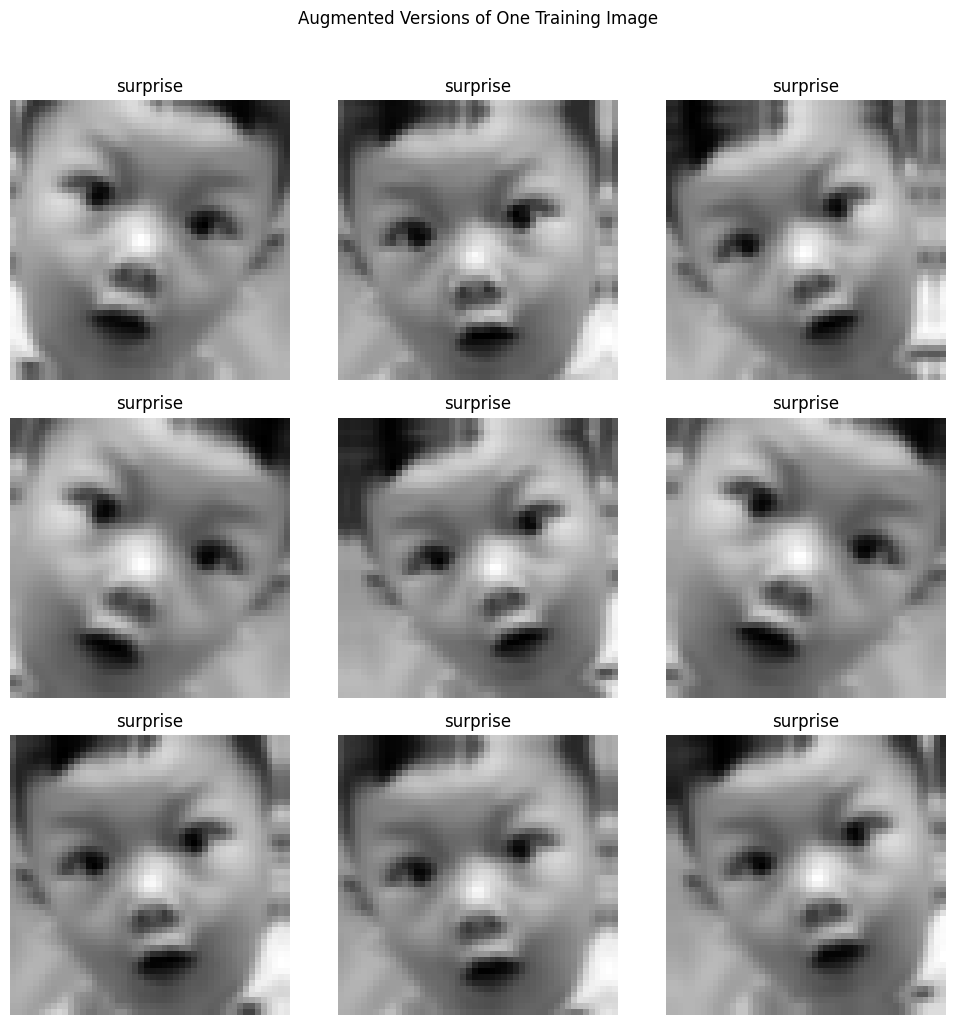

In [ ]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.04, seed=SEED),
    layers.RandomZoom(0.08, seed=SEED),
    layers.RandomTranslation(0.04, 0.04, seed=SEED),
    layers.RandomContrast(0.10, seed=SEED),
], name="mild_data_augmentation")

for images, labels in train_ds.take(1):
    first_image = images[0]

    plt.figure(figsize=(10, 10))
    for i in range(9):
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0), training=True)
        plt.subplot(3, 3, i + 1)
        plt.imshow(tf.squeeze(augmented_image[0]), cmap="gray")
        plt.title(class_names[int(labels[0])])
        plt.axis("off")

    plt.suptitle("Augmented Versions of One Training Image", y=1.02)
    plt.tight_layout()
    plt.show()


### Code explanation
This cell defines reusable utility functions for plotting training curves, collecting labels, evaluating models with classification metrics and confusion matrices, previewing predictions, and creating training callbacks such as checkpoints, early stopping, and learning-rate reduction.


In [ ]:
def plot_history(history, title_prefix):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(9, 5))
    plt.plot(hist["loss"], label="Training Loss")
    plt.plot(hist["val_loss"], label="Validation Loss")
    plt.title(f"{title_prefix}: Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    if "accuracy" in hist.columns:
        plt.figure(figsize=(9, 5))
        plt.plot(hist["accuracy"], label="Training Accuracy")
        plt.plot(hist["val_accuracy"], label="Validation Accuracy")
        plt.title(f"{title_prefix}: Training vs Validation Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

def get_true_labels(dataset):
    return np.concatenate([labels.numpy() for _, labels in dataset], axis=0)

def evaluate_model(model, dataset, class_names, model_name):
    y_true = get_true_labels(dataset)
    y_prob = model.predict(dataset, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    loss, accuracy = model.evaluate(dataset, verbose=0)

    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    print(f"\n{model_name} Evaluation")
    print("-" * 60)
    print(f"Test loss: {loss:.4f}")
    print(f"Test accuracy: {accuracy:.4f}")
    print(f"Weighted precision: {precision_w:.4f}")
    print(f"Weighted recall: {recall_w:.4f}")
    print(f"Weighted F1-score: {f1_w:.4f}")
    print(f"Macro precision: {precision_m:.4f}")
    print(f"Macro recall: {recall_m:.4f}")
    print(f"Macro F1-score: {f1_m:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(9, 7))
    disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
    plt.title(f"{model_name}: Confusion Matrix")
    plt.tight_layout()
    plt.show()

    metrics_dict = {
        "Model": model_name,
        "Test Loss": loss,
        "Test Accuracy": accuracy,
        "Weighted Precision": precision_w,
        "Weighted Recall": recall_w,
        "Weighted F1": f1_w,
        "Macro Precision": precision_m,
        "Macro Recall": recall_m,
        "Macro F1": f1_m,
    }
    return metrics_dict, y_true, y_pred, y_prob

def plot_sample_predictions(model, dataset, class_names, title, n=9):
    for images, labels in dataset.take(1):
        probabilities = model.predict(images, verbose=0)
        predictions = np.argmax(probabilities, axis=1)

        plt.figure(figsize=(12, 10))
        for i in range(min(n, len(images))):
            plt.subplot(3, 3, i + 1)

            image_np = images[i].numpy()
            if image_np.shape[-1] == 1:
                plt.imshow(tf.squeeze(image_np), cmap="gray")
            else:
                plt.imshow(image_np.astype("uint8"))

            true_label = class_names[int(labels[i])]
            pred_label = class_names[int(predictions[i])]
            confidence = float(np.max(probabilities[i]))
            color = "green" if true_label == pred_label else "red"

            plt.title(
                f"True: {true_label}\nPred: {pred_label} ({confidence:.2f})",
                color=color
            )
            plt.axis("off")

        plt.suptitle(title, y=1.02)
        plt.tight_layout()
        plt.show()
        break

def make_callbacks(prefix, monitor="val_loss", mode="min", patience=8):
    return [
        ModelCheckpoint(
            f"{prefix}_best.keras",
            monitor=monitor,
            save_best_only=True,
            mode=mode,
            verbose=1
        ),
        EarlyStopping(
            monitor=monitor,
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor=monitor,
            factor=0.3,
            patience=max(2, patience // 2),
            min_lr=1e-6,
            verbose=1
        )
    ]


# Part A: CNN models from scratch

## Baseline CNN

The baseline is intentionally simple and follows the guideline structure: three convolutional layers, each followed by pooling, then three fully connected layers and a softmax output layer.

### Code explanation
This cell builds the baseline CNN model. The architecture applies augmentation, normalization, three convolution-and-pooling stages, dense layers with dropout, and a softmax output layer for emotion classification.


In [ ]:
def build_baseline_model():
    model = Sequential([
        layers.Input(shape=(48, 48, 1)),
        data_augmentation,
        Rescaling(1./255),

        Conv2D(32, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        Flatten(),

        Dense(256, activation="relu"),
        Dropout(0.30),
        Dense(128, activation="relu"),
        Dropout(0.20),
        Dense(64, activation="relu"),

        Dense(num_classes, activation="softmax")
    ], name="baseline_cnn")

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

baseline_model = build_baseline_model()
baseline_model.summary()


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mild_data_augmentation          │ (None, 48, 48, 1)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,314,183 (5.01 MB)

 Trainable params: 1,314,183 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

### Code explanation
This cell trains the baseline CNN using the prepared training and validation datasets. It applies class weights, callbacks, and records the total training time for later comparison.


In [ ]:
BASELINE_EPOCHS = 30

start_time = time.time()
baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=BASELINE_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks("baseline", monitor="val_loss", mode="min", patience=8),
    verbose=1
)
baseline_training_time = time.time() - start_time

print(f"Baseline training time: {baseline_training_time:.2f} seconds")


Epoch 1/30
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2183 - loss: 1.8134
Epoch 1: val_loss improved from None to 1.81259, saving model to baseline_best.keras

Epoch 1: finished saving model to baseline_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.2349 - loss: 1.7927 - val_accuracy: 0.2596 - val_loss: 1.8126 - learning_rate: 0.0010
Epoch 2/30
417/420 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2760 - loss: 1.7256
Epoch 2: val_loss improved from 1.81259 to 1.59857, saving model to baseline_best.keras

Epoch 2: finished saving model to baseline_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3021 - loss: 1.6963 - val_accuracy: 0.3752 - val_loss: 1.5986 - learning_rate: 0.0010
Epoch 3/30
417/420 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3674 - loss: 1.6034
Epoch 3: val_loss improved from 1.59857 to 1.47257, saving model to baseline_best.keras

Epoch 3: finished saving model to baseline_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━

### Code explanation
This cell plots the baseline model learning curves, evaluates the model on the test set, stores the performance metrics, and displays sample predictions to visually inspect model behavior.


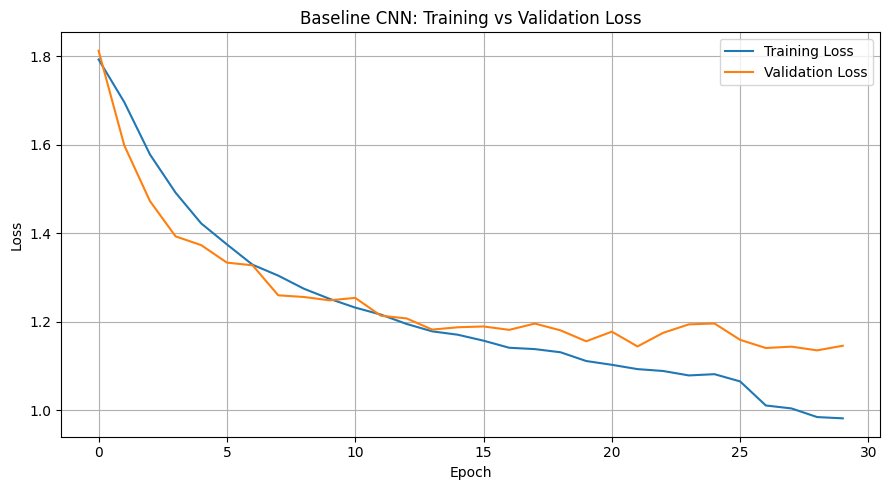

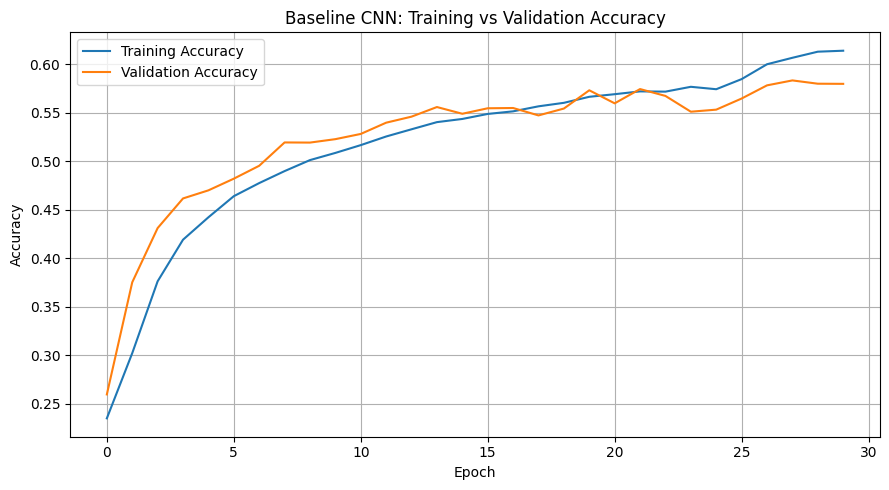


Baseline CNN Evaluation
------------------------------------------------------------
Test loss: 1.2749
Test accuracy: 0.5274
Weighted precision: 0.5227
Weighted recall: 0.5274
Weighted F1-score: 0.5190
Macro precision: 0.5370
Macro recall: 0.5105
Macro F1-score: 0.5135

Classification Report:
              precision    recall  f1-score   support

       angry       0.49      0.48      0.48       300
     disgust       0.67      0.35      0.46       100
        fear       0.38      0.28      0.32       300
       happy       0.66      0.81      0.72       300
     neutral       0.44      0.54      0.49       300
         sad       0.42      0.42      0.42       300
    surprise       0.69      0.70      0.70       300

    accuracy                           0.53      1900
   macro avg       0.54      0.51      0.51      1900
weighted avg       0.52      0.53      0.52      1900



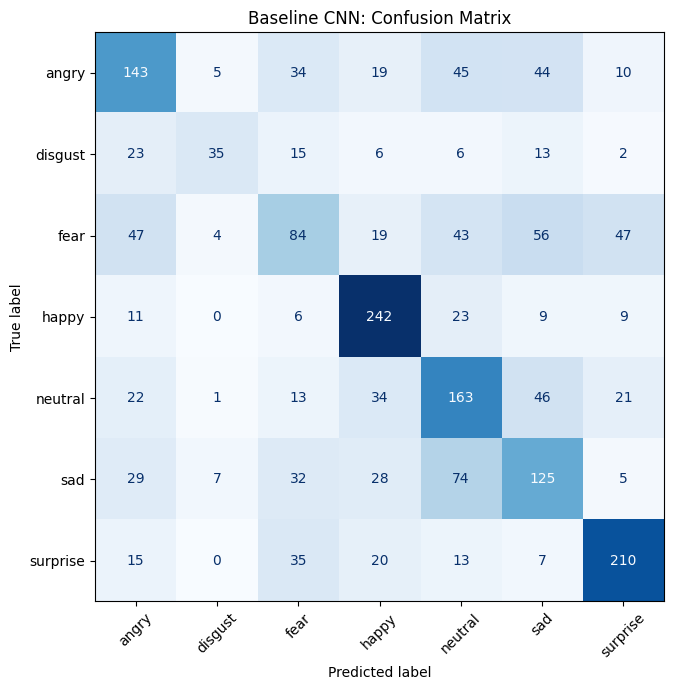

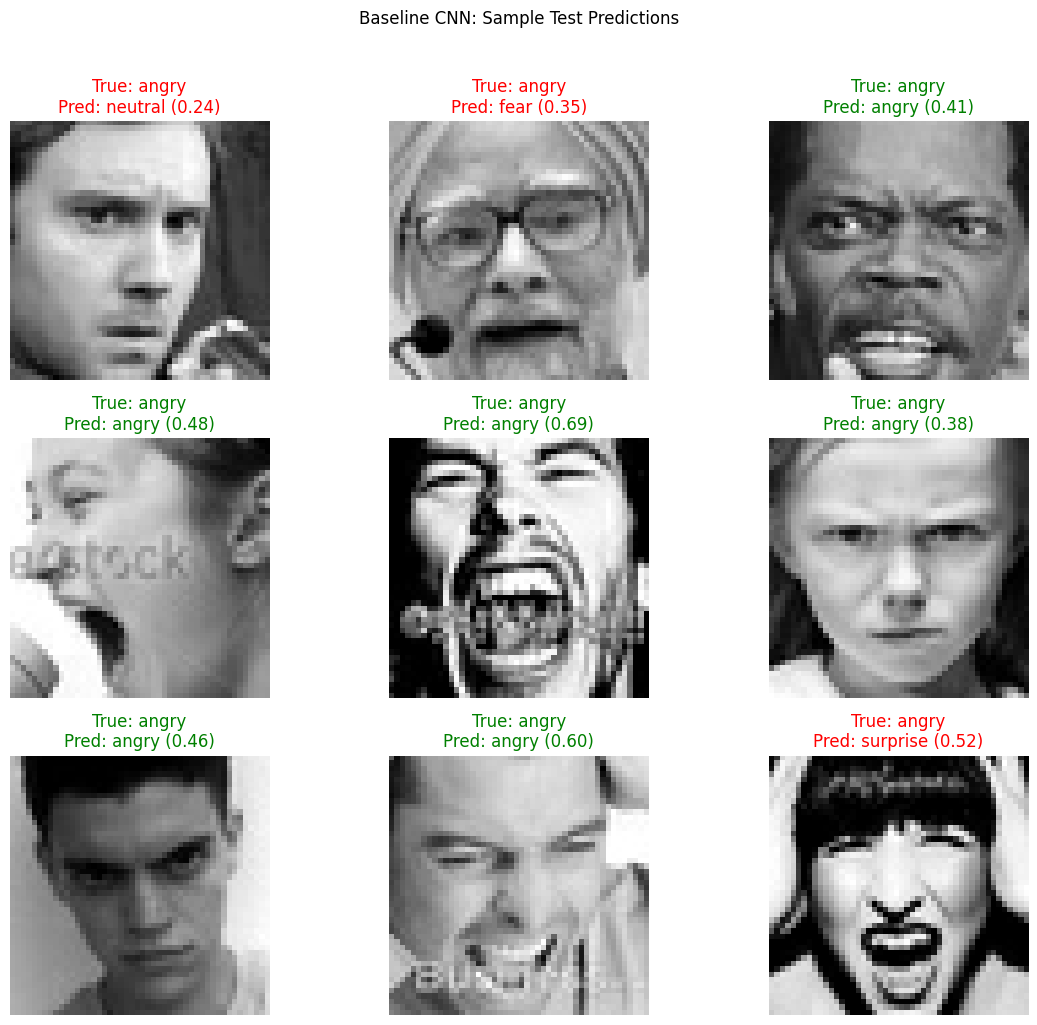

In [ ]:
plot_history(baseline_history, "Baseline CNN")

baseline_metrics, baseline_y_true, baseline_y_pred, baseline_y_prob = evaluate_model(
    baseline_model, test_ds, class_names, "Baseline CNN"
)

plot_sample_predictions(
    baseline_model, test_ds, class_names,
    title="Baseline CNN: Sample Test Predictions"
)


## Deeper CNN with regularization

The deeper model has more than double the number of convolutional layers compared with the baseline. The main improvements are:
- **Batch Normalization** to stabilize training.
- **Dropout** after pooling and dense layers to reduce overfitting.
- **L2 regularization** to discourage overly large weights.
- **GlobalAveragePooling2D** instead of a large Flatten layer to reduce parameters and improve generalization.
- **ReduceLROnPlateau** to lower the learning rate when validation loss stops improving.

### Code explanation
This cell defines a deeper CNN architecture with optional batch normalization and dropout. It uses repeated convolutional blocks, global average pooling, L2 regularization, and dense layers to create a stronger scratch-built model.


In [ ]:
def conv_bn_relu(x, filters, kernel_size=(3, 3), l2_strength=1e-4):
    x = Conv2D(
        filters,
        kernel_size,
        padding="same",
        use_bias=False,
        kernel_regularizer=regularizers.l2(l2_strength)
    )(x)
    x = BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

def build_deeper_model(optimizer=None, include_dropout=True, include_batchnorm=True):
    inputs = layers.Input(shape=(48, 48, 1))
    x = data_augmentation(inputs)
    x = Rescaling(1./255)(x)

    if include_batchnorm:
        x = conv_bn_relu(x, 32)
        x = conv_bn_relu(x, 32)
    else:
        x = Conv2D(32, (3,3), activation="relu", padding="same")(x)
        x = Conv2D(32, (3,3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)
    if include_dropout:
        x = Dropout(0.20)(x)

    if include_batchnorm:
        x = conv_bn_relu(x, 64)
        x = conv_bn_relu(x, 64)
    else:
        x = Conv2D(64, (3,3), activation="relu", padding="same")(x)
        x = Conv2D(64, (3,3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)
    if include_dropout:
        x = Dropout(0.25)(x)

    if include_batchnorm:
        x = conv_bn_relu(x, 128)
        x = conv_bn_relu(x, 128)
    else:
        x = Conv2D(128, (3,3), activation="relu", padding="same")(x)
        x = Conv2D(128, (3,3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)
    if include_dropout:
        x = Dropout(0.30)(x)

    if include_batchnorm:
        x = conv_bn_relu(x, 256)
        x = conv_bn_relu(x, 256)
    else:
        x = Conv2D(256, (3,3), activation="relu", padding="same")(x)
        x = Conv2D(256, (3,3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)
    if include_dropout:
        x = Dropout(0.35)(x)

    x = GlobalAveragePooling2D()(x)

    x = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    if include_dropout:
        x = Dropout(0.45)(x)
    x = Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    if include_dropout:
        x = Dropout(0.30)(x)
    x = Dense(64, activation="relu")(x)

    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs, name="deeper_regularized_cnn")

    if optimizer is None:
        optimizer = Adam(learning_rate=1e-3)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

deeper_model = build_deeper_model()
deeper_model.summary()


Model: "deeper_regularized_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mild_data_augmentation          │ (None, 48, 48, 1)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 128)    │             

 Total params: 1,281,959 (4.89 MB)

 Trainable params: 1,280,039 (4.88 MB)

 Non-trainable params: 1,920 (7.50 KB)

### Code explanation
This cell trains the deeper regularized CNN for more epochs than the baseline. It uses the same class weights and callbacks, then records the training duration for the final model comparison.


In [ ]:
DEEPER_EPOCHS = 60

start_time = time.time()
deeper_history = deeper_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=DEEPER_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks("deeper_cnn", monitor="val_loss", mode="min", patience=10),
    verbose=1
)
deeper_training_time = time.time() - start_time

print(f"Deeper model training time: {deeper_training_time:.2f} seconds")


Epoch 1/60
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.2282 - loss: 1.9369
Epoch 1: val_loss improved from None to 1.90664, saving model to deeper_cnn_best.keras

Epoch 1: finished saving model to deeper_cnn_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.2505 - loss: 1.8806 - val_accuracy: 0.2678 - val_loss: 1.9066 - learning_rate: 0.0010
Epoch 2/60
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3074 - loss: 1.7823
Epoch 2: val_loss improved from 1.90664 to 1.87097, saving model to deeper_cnn_best.keras

Epoch 2: finished saving model to deeper_cnn_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.3191 - loss: 1.7577 - val_accuracy: 0.2985 - val_loss: 1.8710 - learning_rate: 0.0010
Epoch 3/60
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3754 - loss: 1.6744
Epoch 3: val_loss did not improve from 1.87097
420/420 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.3977 - loss: 1.6331 - val_accuracy: 0.2605 - val_loss: 1.9

### Code explanation
This cell plots the deeper CNN training history, evaluates it on the test set, stores its metrics and predictions, and shows sample predictions from the test dataset.


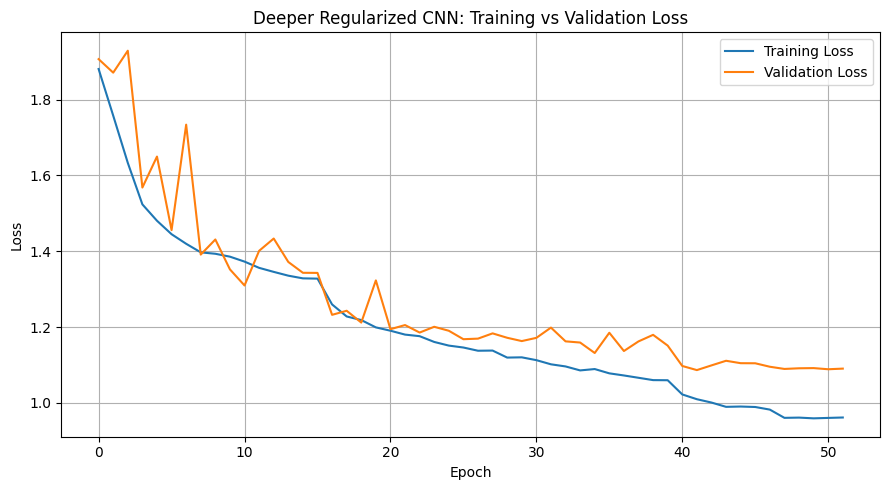

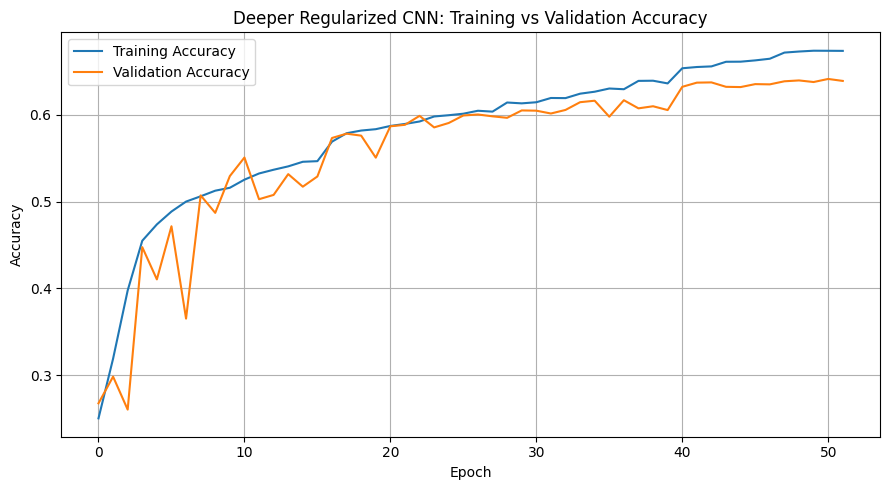


Deeper Regularized CNN Evaluation
------------------------------------------------------------
Test loss: 1.2250
Test accuracy: 0.5895
Weighted precision: 0.5972
Weighted recall: 0.5895
Weighted F1-score: 0.5799
Macro precision: 0.6086
Macro recall: 0.5790
Macro F1-score: 0.5795

Classification Report:
              precision    recall  f1-score   support

       angry       0.54      0.53      0.53       300
     disgust       0.72      0.48      0.57       100
        fear       0.50      0.25      0.33       300
       happy       0.74      0.87      0.80       300
     neutral       0.47      0.70      0.56       300
         sad       0.47      0.53      0.50       300
    surprise       0.82      0.70      0.75       300

    accuracy                           0.59      1900
   macro avg       0.61      0.58      0.58      1900
weighted avg       0.60      0.59      0.58      1900



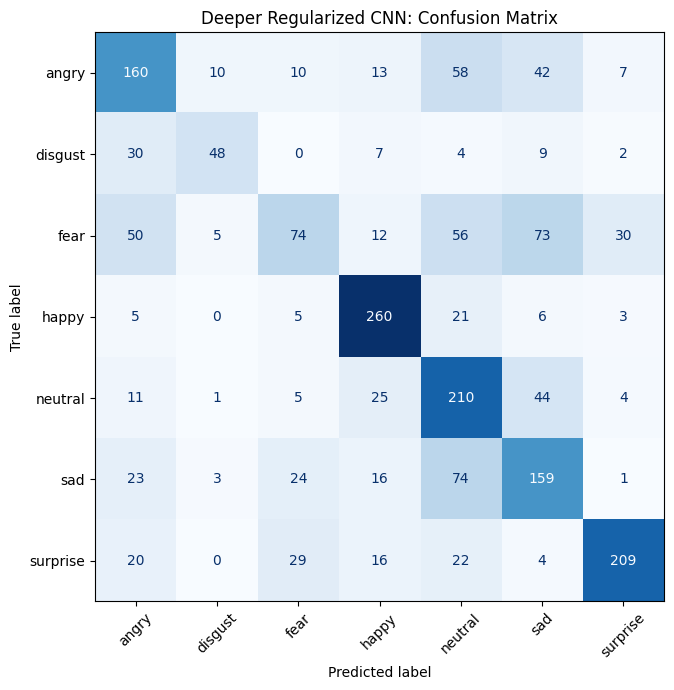

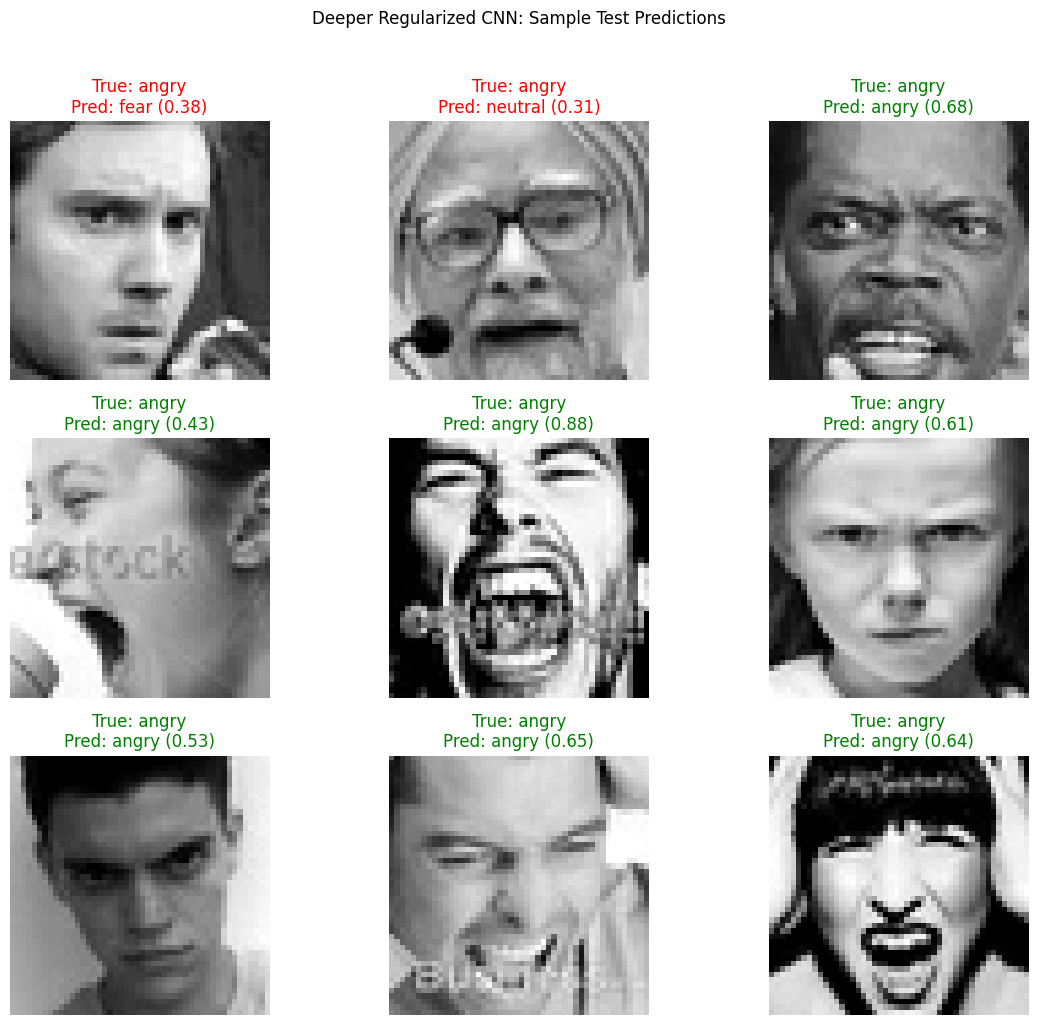

In [ ]:
plot_history(deeper_history, "Deeper Regularized CNN")

deeper_metrics, deeper_y_true, deeper_y_pred, deeper_y_prob = evaluate_model(
    deeper_model, test_ds, class_names, "Deeper Regularized CNN"
)

plot_sample_predictions(
    deeper_model, test_ds, class_names,
    title="Deeper Regularized CNN: Sample Test Predictions"
)


## Optimizer analysis: SGD vs Adam

Both models below use the same deeper architecture and the same data pipeline. This makes the comparison fairer because the optimizer is the main changed variable.

### Code explanation
This cell compares two optimizers using the same deeper CNN structure. It trains one model with SGD plus momentum and another with Adam, evaluates both models, stores their metrics, and plots their training histories.


Epoch 1/25
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2210 - loss: 1.9522
Epoch 1: val_loss improved from None to 1.95995, saving model to deeper_sgd_best.keras

Epoch 1: finished saving model to deeper_sgd_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.2352 - loss: 1.9175 - val_accuracy: 0.2583 - val_loss: 1.9599 - learning_rate: 0.0100
Epoch 2/25
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2661 - loss: 1.8685
Epoch 2: val_loss did not improve from 1.95995
420/420 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.2832 - loss: 1.8432 - val_accuracy: 0.2571 - val_loss: 2.1117 - learning_rate: 0.0100
Epoch 3/25
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3166 - loss: 1.7891
Epoch 3: val_loss improved from 1.95995 to 1.92304, saving model to deeper_sgd_best.keras

Epoch 3: finished saving model to deeper_sgd_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.3221 - loss: 1.7701 - val_accuracy: 0.3167 - val_loss: 1.9

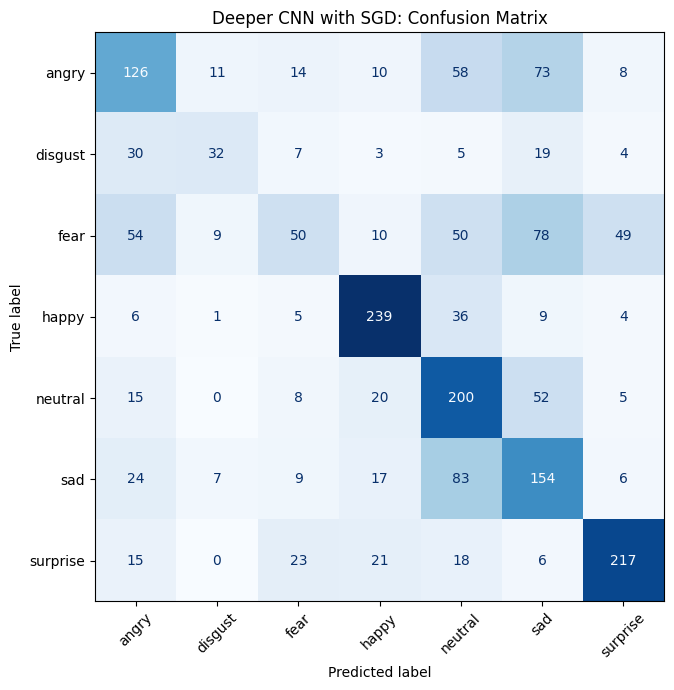

Epoch 1/25
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2168 - loss: 1.9321
Epoch 1: val_loss improved from None to 1.94889, saving model to deeper_adam_best.keras

Epoch 1: finished saving model to deeper_adam_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 25s 44ms/step - accuracy: 0.2348 - loss: 1.9049 - val_accuracy: 0.2586 - val_loss: 1.9489 - learning_rate: 0.0010
Epoch 2/25
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.2830 - loss: 1.8237
Epoch 2: val_loss improved from 1.94889 to 1.83910, saving model to deeper_adam_best.keras

Epoch 2: finished saving model to deeper_adam_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.2939 - loss: 1.7997 - val_accuracy: 0.2911 - val_loss: 1.8391 - learning_rate: 0.0010
Epoch 3/25
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3443 - loss: 1.7118
Epoch 3: val_loss improved from 1.83910 to 1.61427, saving model to deeper_adam_best.keras

Epoch 3: finished saving model to deeper_adam_best.keras
420/420 ━

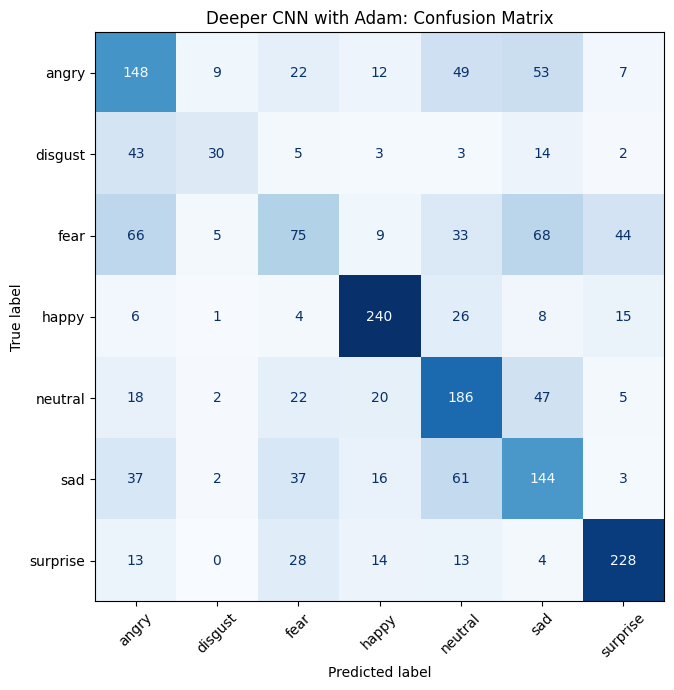

,Model,Test Loss,Test Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1,Training Time (seconds)
0,Deeper CNN with SGD,1.329004,0.535789,0.537043,0.535789,0.520694,0.53669,0.515238,0.509199,422.480599
1,Deeper CNN with Adam,1.253546,0.553158,0.549715,0.553158,0.544755,0.55567,0.529048,0.531225,461.729894


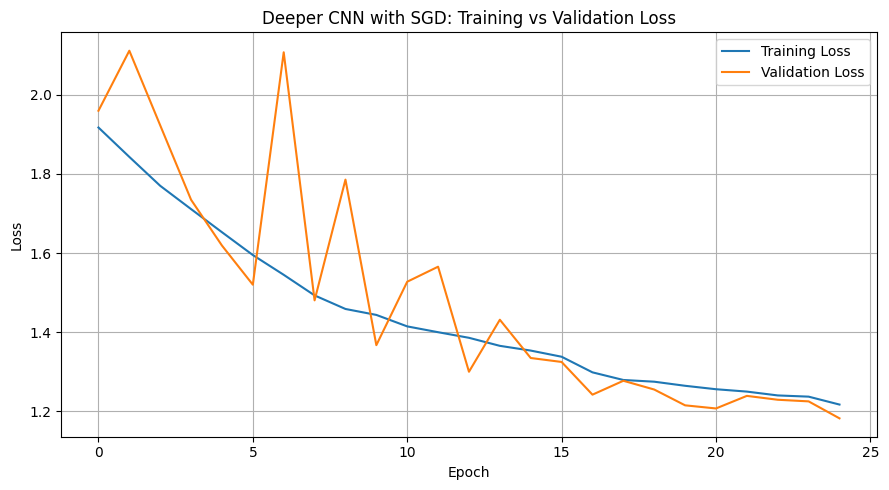

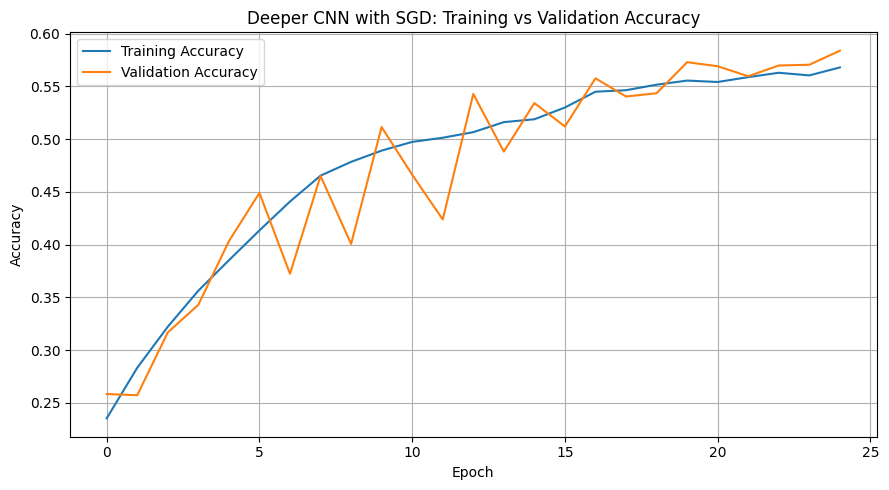

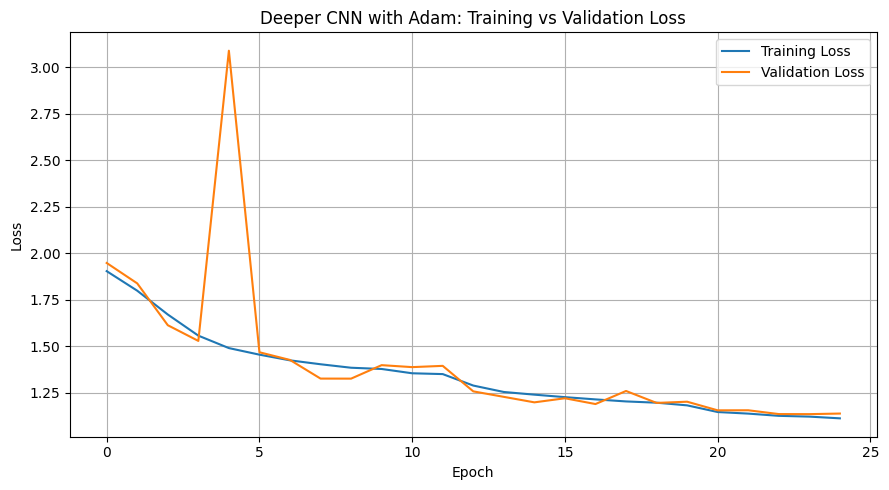

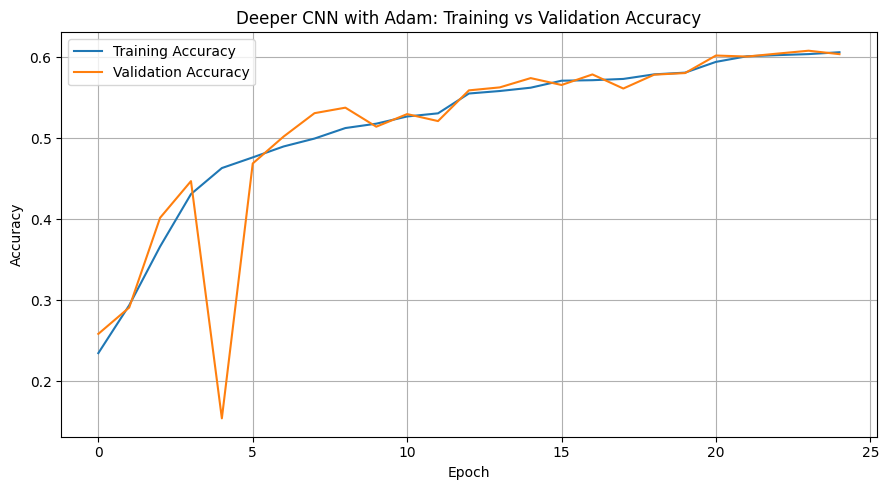

In [ ]:
OPTIMIZER_EPOCHS = 25

optimizer_results = []

sgd_model = build_deeper_model(
    optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
)

start_time = time.time()
sgd_history = sgd_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=OPTIMIZER_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks("deeper_sgd", monitor="val_loss", mode="min", patience=6),
    verbose=1
)
sgd_training_time = time.time() - start_time

sgd_metrics, _, _, _ = evaluate_model(sgd_model, test_ds, class_names, "Deeper CNN with SGD")
sgd_metrics["Training Time (seconds)"] = sgd_training_time
optimizer_results.append(sgd_metrics)

adam_model = build_deeper_model(
    optimizer=Adam(learning_rate=1e-3)
)

start_time = time.time()
adam_history = adam_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=OPTIMIZER_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks("deeper_adam", monitor="val_loss", mode="min", patience=6),
    verbose=1
)
adam_training_time = time.time() - start_time

adam_metrics, _, _, _ = evaluate_model(adam_model, test_ds, class_names, "Deeper CNN with Adam")
adam_metrics["Training Time (seconds)"] = adam_training_time
optimizer_results.append(adam_metrics)

optimizer_df = pd.DataFrame(optimizer_results)
display(optimizer_df)

plot_history(sgd_history, "Deeper CNN with SGD")
plot_history(adam_history, "Deeper CNN with Adam")


## Ablation study: removing dropout

Dropout is removed from the deeper CNN while keeping the rest of the model similar. If validation performance becomes worse or the training-validation gap increases, it suggests that dropout was helping the model generalize.

### Code explanation
This cell performs an ablation study by training the deeper CNN without dropout while keeping batch normalization enabled. The results help measure how much dropout contributes to generalization and overfitting control.


Model: "deeper_regularized_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mild_data_augmentation          │ (None, 48, 48, 1)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 48, 48, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 48, 48, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 24, 24, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 24, 24, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 12, 12, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 12, 12, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 12, 12, 128)    │           51

 Total params: 1,281,959 (4.89 MB)

 Trainable params: 1,280,039 (4.88 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/25
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2876 - loss: 1.8303
Epoch 1: val_loss improved from None to 1.62728, saving model to ablation_no_dropout_best.keras

Epoch 1: finished saving model to ablation_no_dropout_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - accuracy: 0.3504 - loss: 1.7200 - val_accuracy: 0.4222 - val_loss: 1.6273 - learning_rate: 0.0010
Epoch 2/25
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4590 - loss: 1.5038
Epoch 2: val_loss improved from 1.62728 to 1.56659, saving model to ablation_no_dropout_best.keras

Epoch 2: finished saving model to ablation_no_dropout_best.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.4731 - loss: 1.4731 - val_accuracy: 0.4731 - val_loss: 1.5666 - learning_rate: 0.0010
Epoch 3/25
419/420 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5130 - loss: 1.3733
Epoch 3: val_loss improved from 1.56659 to 1.48936, saving model to ablation_no_dropout_best.keras

Epoch 3: finished saving m

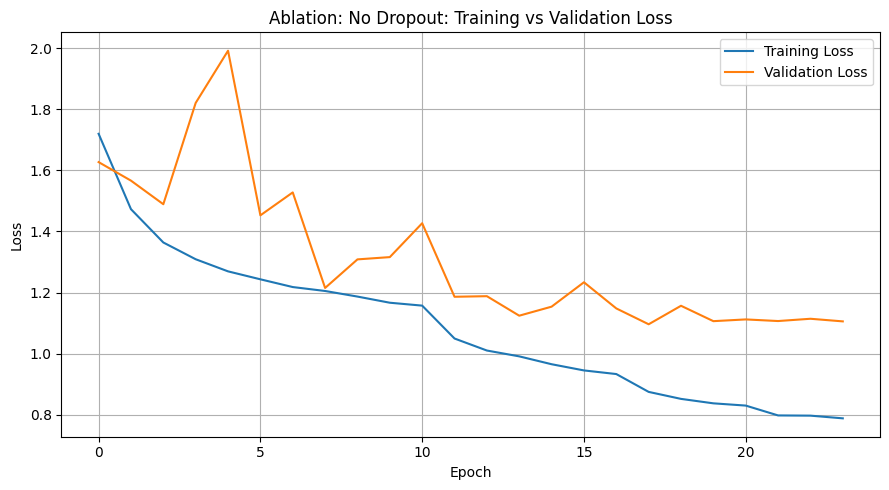

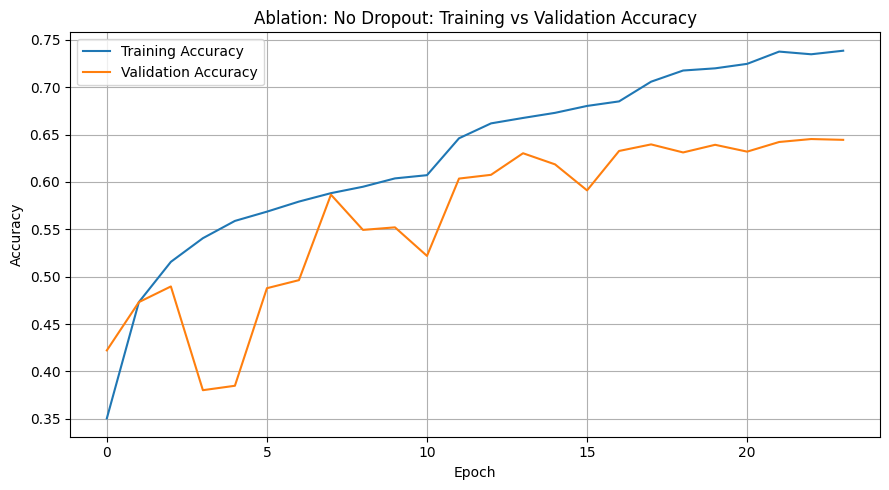


Ablation: Deeper CNN without Dropout Evaluation
------------------------------------------------------------
Test loss: 1.2192
Test accuracy: 0.6005
Weighted precision: 0.6031
Weighted recall: 0.6005
Weighted F1-score: 0.5957
Macro precision: 0.6222
Macro recall: 0.5862
Macro F1-score: 0.5939

Classification Report:
              precision    recall  f1-score   support

       angry       0.54      0.57      0.55       300
     disgust       0.80      0.45      0.58       100
        fear       0.50      0.37      0.43       300
       happy       0.72      0.89      0.79       300
     neutral       0.55      0.57      0.56       300
         sad       0.45      0.50      0.47       300
    surprise       0.81      0.75      0.78       300

    accuracy                           0.60      1900
   macro avg       0.62      0.59      0.59      1900
weighted avg       0.60      0.60      0.60      1900



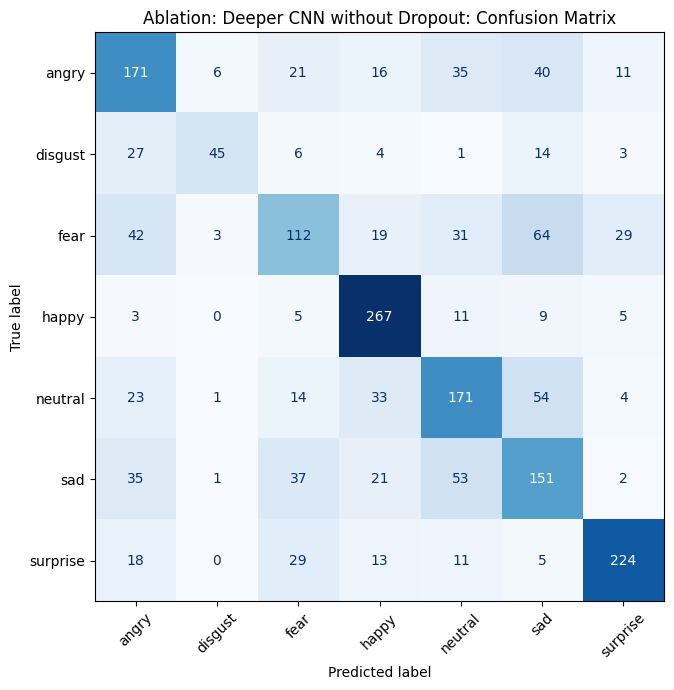

In [ ]:
ablation_no_dropout_model = build_deeper_model(
    optimizer=Adam(learning_rate=1e-3),
    include_dropout=False,
    include_batchnorm=True
)

ablation_no_dropout_model.summary()

ABLATION_EPOCHS = 25

start_time = time.time()
ablation_history = ablation_no_dropout_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=ABLATION_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks("ablation_no_dropout", monitor="val_loss", mode="min", patience=6),
    verbose=1
)
ablation_training_time = time.time() - start_time

plot_history(ablation_history, "Ablation: No Dropout")

ablation_metrics, _, _, _ = evaluate_model(
    ablation_no_dropout_model,
    test_ds,
    class_names,
    "Ablation: Deeper CNN without Dropout"
)
ablation_metrics["Training Time (seconds)"] = ablation_training_time


# Part B: Transfer learning

This section adapts ideas from the uploaded `facial-expression-based-emotion-recognition` notebook while keeping the workflow aligned with the assignment.

Key improvements over the earlier transfer-learning block:
- use a stronger **MobileNetV3Large** ImageNet backbone
- convert grayscale images to **224×224 RGB** for compatibility with the pre-trained model
- add a lightweight **PointAttention** block after the convolutional base
- train in two stages:
  1. **feature extraction** with the backbone frozen
  2. **fine-tuning** by unfreezing only the upper layers with a smaller learning rate

This gives a more facial-expression-focused transfer-learning pipeline without breaking the assignment structure.

### Code explanation
This cell prepares separate RGB datasets for transfer learning. Images are resized to 224×224 and loaded in RGB format so they match the expected input shape for the pre-trained MobileNetV3Large backbone.


In [ ]:
TRANSFER_SIZE = (224, 224)
TRANSFER_BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

transfer_train_ds = tf.keras.utils.image_dataset_from_directory(
    train_data_dir,
    image_size=TRANSFER_SIZE,
    color_mode="rgb",
    batch_size=TRANSFER_BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
).prefetch(AUTOTUNE)

transfer_val_ds = tf.keras.utils.image_dataset_from_directory(
    validation_data_dir,
    image_size=TRANSFER_SIZE,
    color_mode="rgb",
    batch_size=TRANSFER_BATCH_SIZE,
    label_mode="int",
    shuffle=False
).prefetch(AUTOTUNE)

transfer_test_ds = tf.keras.utils.image_dataset_from_directory(
    test_data_dir,
    image_size=TRANSFER_SIZE,
    color_mode="rgb",
    batch_size=TRANSFER_BATCH_SIZE,
    label_mode="int",
    shuffle=False
).prefetch(AUTOTUNE)


Found 26872 files belonging to 7 classes.
Found 7066 files belonging to 7 classes.
Found 1900 files belonging to 7 classes.


### Code explanation
This cell builds the transfer-learning model. It loads MobileNetV3Large with ImageNet weights, adds a custom PointAttention layer, applies pooling and dense classifier layers, compiles the model, and prints the model summary.


In [ ]:
from tensorflow.keras.applications import MobileNetV3Large

@tf.keras.utils.register_keras_serializable()
class PointAttention(layers.Layer):
    def __init__(self, reduction_ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        channels = int(input_shape[-1])
        reduced_channels = max(channels // self.reduction_ratio, 8)

        self.gap = layers.GlobalAveragePooling2D()
        self.gmp = layers.GlobalMaxPooling2D()
        self.fc1 = layers.Dense(reduced_channels, activation="relu", use_bias=False)
        self.fc2 = layers.Dense(channels, use_bias=False)
        self.spatial_conv = layers.Conv2D(
            1, kernel_size=7, padding="same", activation="sigmoid", use_bias=False
        )
        super().build(input_shape)

    def call(self, inputs):
        avg = self.fc2(self.fc1(self.gap(inputs)))
        mx = self.fc2(self.fc1(self.gmp(inputs)))
        channel_attention = tf.nn.sigmoid(avg + mx)
        channel_attention = tf.reshape(channel_attention, (-1, 1, 1, tf.shape(inputs)[-1]))
        x = inputs * channel_attention

        avg_map = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_map = tf.reduce_max(x, axis=-1, keepdims=True)
        spatial_attention = self.spatial_conv(tf.concat([avg_map, max_map], axis=-1))
        return x * spatial_attention

    def get_config(self):
        config = super().get_config()
        config.update({"reduction_ratio": self.reduction_ratio})
        return config

transfer_augmentation = Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.05, seed=SEED),
    layers.RandomZoom(0.08, seed=SEED),
    layers.RandomContrast(0.10, seed=SEED),
], name="transfer_augmentation")

def build_transfer_model(input_shape=(224, 224, 3), num_classes=7):
    base_model = MobileNetV3Large(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape,
        include_preprocessing=True
    )
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = transfer_augmentation(inputs)
    x = base_model(x, training=False)
    x = PointAttention(reduction_ratio=8, name="point_attention")(x)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = Dropout(0.40)(x)
    x = Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = Dropout(0.30)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs, name="mobilenetv3large_pointattention")
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model, base_model

transfer_model, base_model = build_transfer_model(
    input_shape=(TRANSFER_SIZE[0], TRANSFER_SIZE[1], 3),
    num_classes=num_classes
)
transfer_model.summary()


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv3large_pointattention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_augmentation           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ point_attention                 │ (None, 7, 7, 960)      │       230,498 │
│ (PointAttention)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,510,505 (13.39 MB)

 Trainable params: 512,233 (1.95 MB)

 Non-trainable params: 2,998,272 (11.44 MB)

### Code explanation
This cell trains the transfer model in feature-extraction mode with the MobileNetV3Large backbone frozen. It records training time and plots the learning curves for this first transfer-learning stage.


Epoch 1/15
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2657 - loss: 1.8347
Epoch 1: val_accuracy improved from None to 0.45754, saving model to transfer_feature_extraction_best.keras

Epoch 1: finished saving model to transfer_feature_extraction_best.keras
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 93s 50ms/step - accuracy: 0.3293 - loss: 1.7247 - val_accuracy: 0.4575 - val_loss: 1.5067 - learning_rate: 0.0010
Epoch 2/15
1679/1680 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4148 - loss: 1.5770
Epoch 2: val_accuracy improved from 0.45754 to 0.48203, saving model to transfer_feature_extraction_best.keras

Epoch 2: finished saving model to transfer_feature_extraction_best.keras
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - accuracy: 0.4216 - loss: 1.5541 - val_accuracy: 0.4820 - val_loss: 1.4587 - learning_rate: 0.0010
Epoch 3/15
1678/1680 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4363 - loss: 1.5112
Epoch 3: val_accuracy improved from 0.48203 to 0.49476, saving model to tran

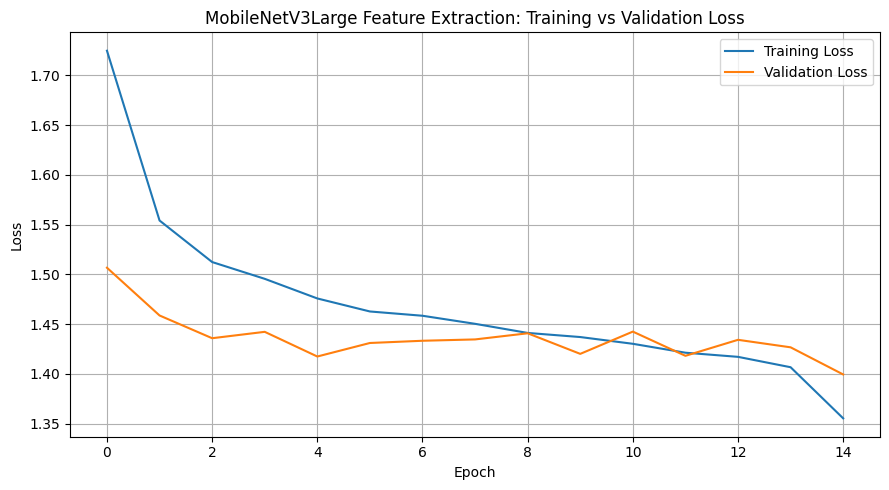

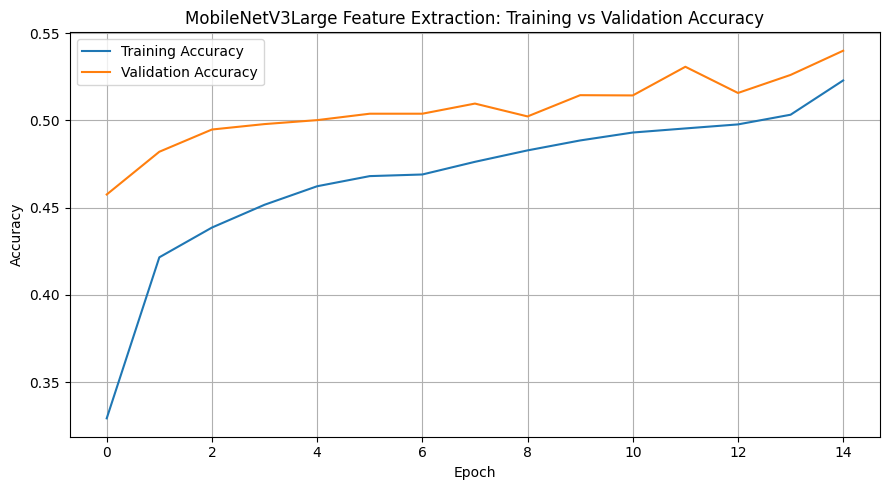

In [ ]:
FEATURE_EPOCHS = 15

start_time = time.time()
transfer_history = transfer_model.fit(
    transfer_train_ds,
    validation_data=transfer_val_ds,
    epochs=FEATURE_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks(
        "transfer_feature_extraction",
        monitor="val_accuracy",
        mode="max",
        patience=5
    ),
    verbose=1
)
transfer_feature_time = time.time() - start_time

print(f"Transfer feature extraction training time: {transfer_feature_time:.2f} seconds")
plot_history(transfer_history, "MobileNetV3Large Feature Extraction")


### Code explanation
This cell fine-tunes the upper layers of the MobileNetV3Large backbone. Earlier layers remain frozen, batch-normalization layers are protected from unstable updates, and the model is recompiled with a low learning rate before training.


Total base model layers: 187
Fine-tuning from layer index: 121
Trainable layers in full model: 11
Epoch 1/20
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5360 - loss: 1.3248
Epoch 1: val_accuracy improved from None to 0.56411, saving model to transfer_fine_tuned_best.keras

Epoch 1: finished saving model to transfer_fine_tuned_best.keras
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 126s 68ms/step - accuracy: 0.5480 - loss: 1.2918 - val_accuracy: 0.5641 - val_loss: 1.3183 - learning_rate: 1.0000e-05
Epoch 2/20
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5573 - loss: 1.2728
Epoch 2: val_accuracy improved from 0.56411 to 0.57373, saving model to transfer_fine_tuned_best.keras

Epoch 2: finished saving model to transfer_fine_tuned_best.keras
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 104s 62ms/step - accuracy: 0.5636 - loss: 1.2456 - val_accuracy: 0.5737 - val_loss: 1.2861 - learning_rate: 1.0000e-05
Epoch 3/20
1679/1680 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5752 - loss: 1.2264


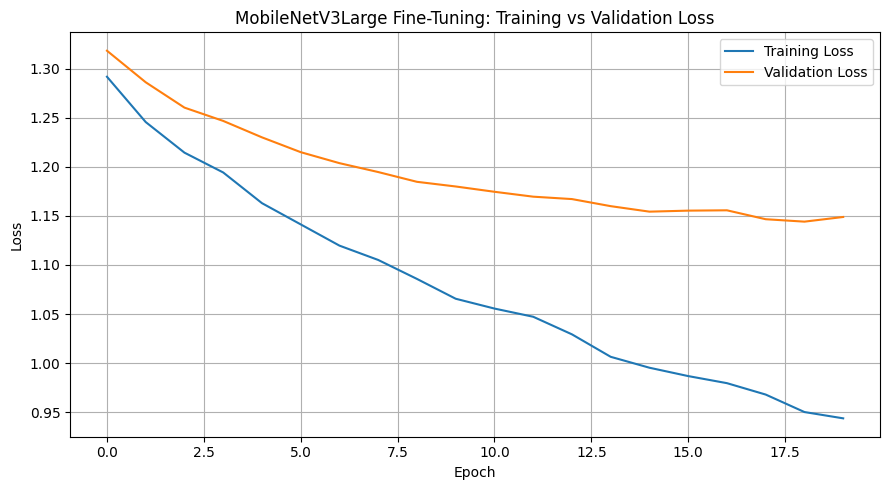

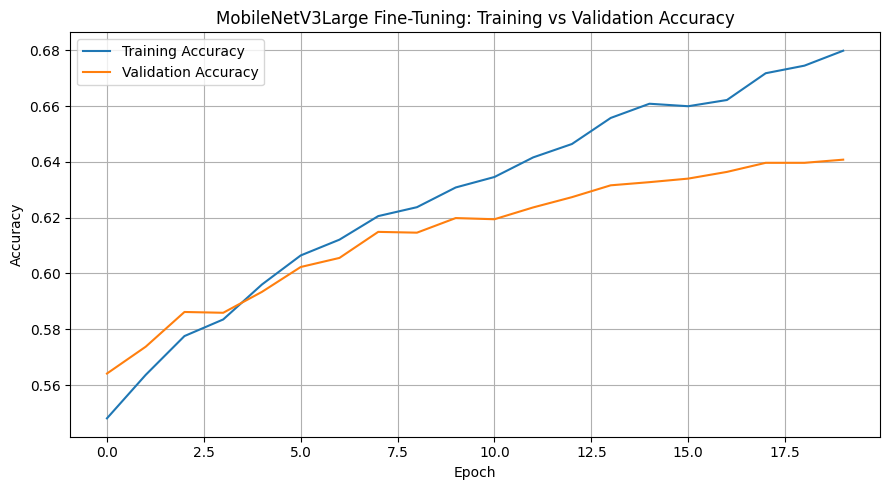

In [ ]:
base_model.trainable = True

fine_tune_at = int(len(base_model.layers) * 0.65)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Total base model layers:", len(base_model.layers))
print("Fine-tuning from layer index:", fine_tune_at)
print("Trainable layers in full model:", sum(layer.trainable for layer in transfer_model.layers))

FINE_TUNE_EPOCHS = 20

start_time = time.time()
fine_tune_history = transfer_model.fit(
    transfer_train_ds,
    validation_data=transfer_val_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks(
        "transfer_fine_tuned",
        monitor="val_accuracy",
        mode="max",
        patience=6
    ),
    verbose=1
)
transfer_fine_tune_time = time.time() - start_time

print(f"Transfer fine-tuning time: {transfer_fine_tune_time:.2f} seconds")
plot_history(fine_tune_history, "MobileNetV3Large Fine-Tuning")


### Code explanation
This cell evaluates the fine-tuned transfer-learning model on the transfer test dataset. It stores the combined training time and displays sample test predictions for qualitative inspection.



MobileNetV3Large + PointAttention Transfer Learning Evaluation
------------------------------------------------------------
Test loss: 1.3272
Test accuracy: 0.5795
Weighted precision: 0.5911
Weighted recall: 0.5795
Weighted F1-score: 0.5783
Macro precision: 0.6179
Macro recall: 0.5700
Macro F1-score: 0.5822

Classification Report:
              precision    recall  f1-score   support

       angry       0.55      0.54      0.55       300
     disgust       0.87      0.48      0.62       100
        fear       0.49      0.36      0.42       300
       happy       0.72      0.79      0.75       300
     neutral       0.49      0.64      0.56       300
         sad       0.43      0.48      0.45       300
    surprise       0.78      0.69      0.73       300

    accuracy                           0.58      1900
   macro avg       0.62      0.57      0.58      1900
weighted avg       0.59      0.58      0.58      1900



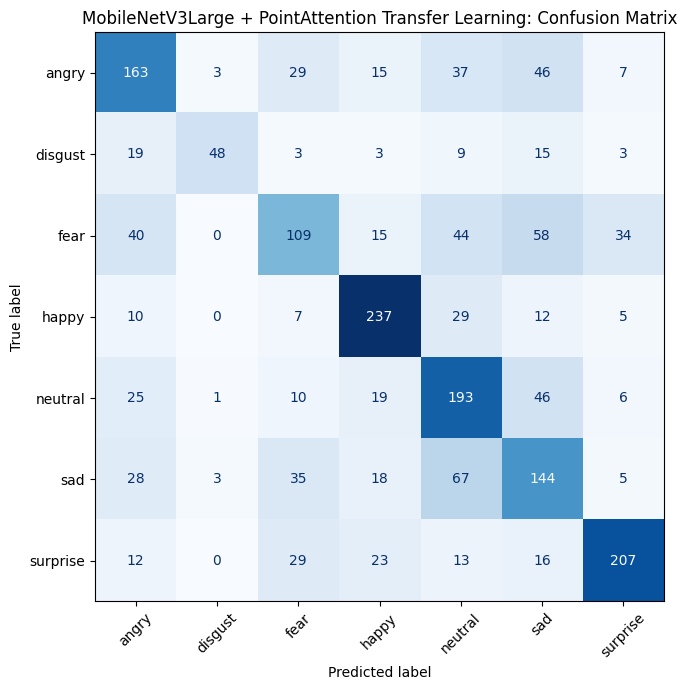

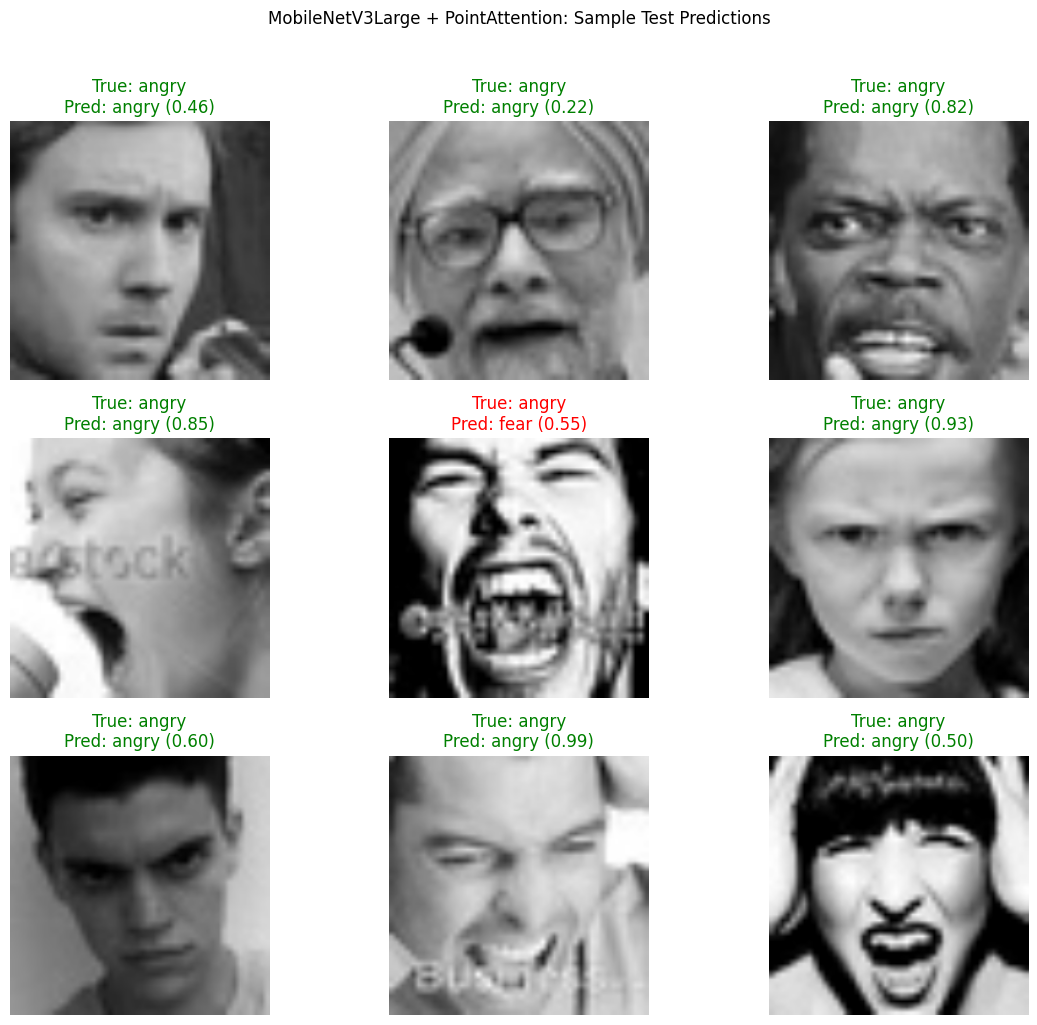

In [ ]:
transfer_metrics, transfer_y_true, transfer_y_pred, transfer_y_prob = evaluate_model(
    transfer_model,
    transfer_test_ds,
    class_names,
    "MobileNetV3Large + PointAttention Transfer Learning"
)

transfer_metrics["Training Time (seconds)"] = transfer_feature_time + transfer_fine_tune_time

plot_sample_predictions(
    transfer_model,
    transfer_test_ds,
    class_names,
    title="MobileNetV3Large + PointAttention: Sample Test Predictions"
)


# Final comparative analysis

This section compares the major experiments required in the assignment:
- baseline CNN from scratch
- deeper regularized CNN
- optimizer comparison (SGD vs Adam)
- ablation study
- transfer learning / fine-tuning

Use the output table and plots below as evidence for the report discussion on:
- model accuracy and loss
- optimizer behavior
- regularization effects
- computational trade-offs
- whether transfer learning outperforms training from scratch

### Code explanation
This cell combines the metrics from all experiments into a final comparison table. It rounds numeric values, displays the results, and plots accuracy and training-time comparisons across models.


,Model,Test Loss,Test Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1,Training Time (seconds)
0,Baseline CNN,1.2749,0.5274,0.5227,0.5274,0.5190,0.5370,0.5105,0.5135,194.2302
1,Deeper Regularized CNN,1.2250,0.5895,0.5972,0.5895,0.5799,0.6086,0.5790,0.5795,944.1925
2,Deeper CNN with SGD,1.3290,0.5358,0.5370,0.5358,0.5207,0.5367,0.5152,0.5092,422.4806
3,Deeper CNN with Adam,1.2535,0.5532,0.5497,0.5532,0.5448,0.5557,0.5290,0.5312,461.7299
4,Ablation: Deeper CNN without Dropout,1.2192,0.6005,0.6031,0.6005,0.5957,0.6222,0.5862,0.5939,424.4335
5,MobileNetV3Large + PointAttention Transfer Lea...,1.3272,0.5795,0.5911,0.5795,0.5783,0.6179,0.5700,0.5822,3367.1137


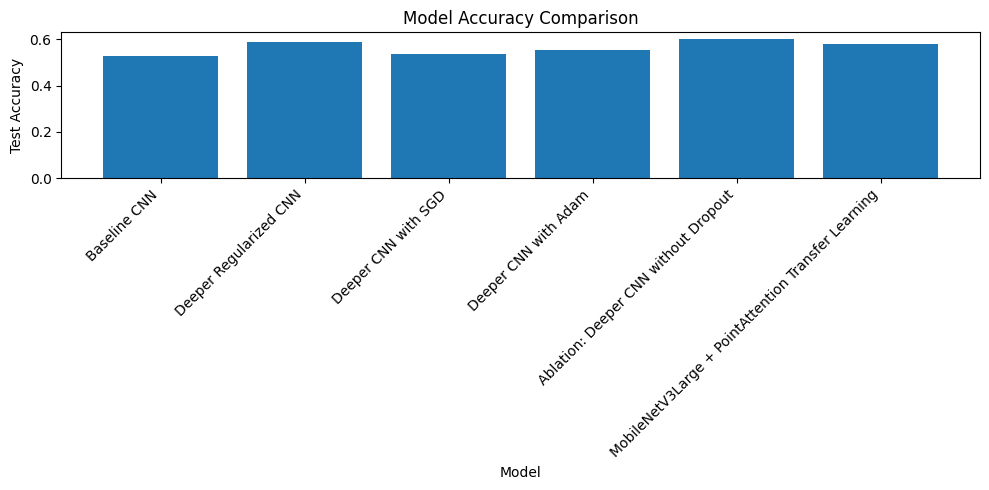

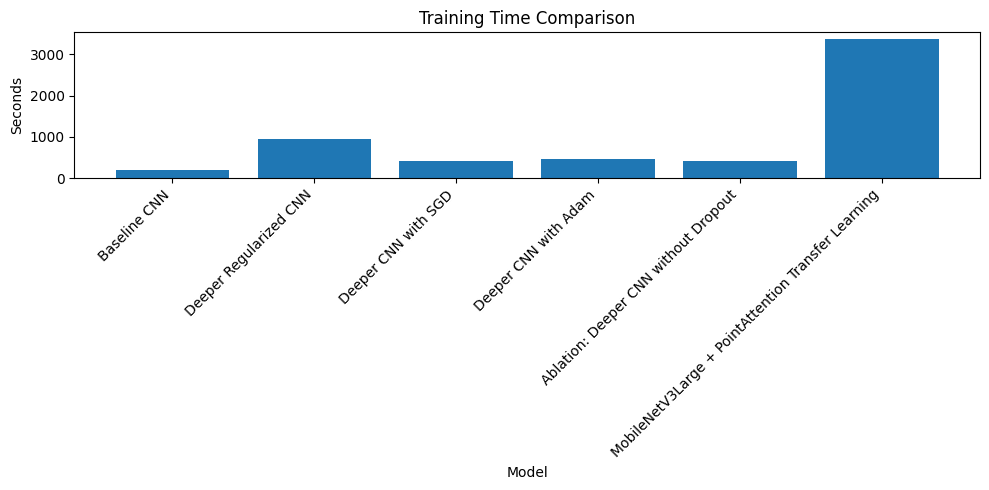

In [ ]:
baseline_metrics["Training Time (seconds)"] = baseline_training_time
deeper_metrics["Training Time (seconds)"] = deeper_training_time

comparison_df = pd.DataFrame([
    baseline_metrics,
    deeper_metrics,
    sgd_metrics,
    adam_metrics,
    ablation_metrics,
    transfer_metrics
])

numeric_cols = comparison_df.select_dtypes(include=[np.number]).columns
comparison_df[numeric_cols] = comparison_df[numeric_cols].round(4)

display(comparison_df)

plt.figure(figsize=(10, 5))
plt.bar(comparison_df["Model"], comparison_df["Test Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(comparison_df["Model"], comparison_df["Training Time (seconds)"])
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Seconds")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Code explanation
This cell identifies the best model from the comparison table and visualizes several misclassified test examples. The output helps analyze which classes or images the selected model finds difficult.


Best model based on test accuracy: Ablation: Deeper CNN without Dropout
Number of misclassified examples: 780


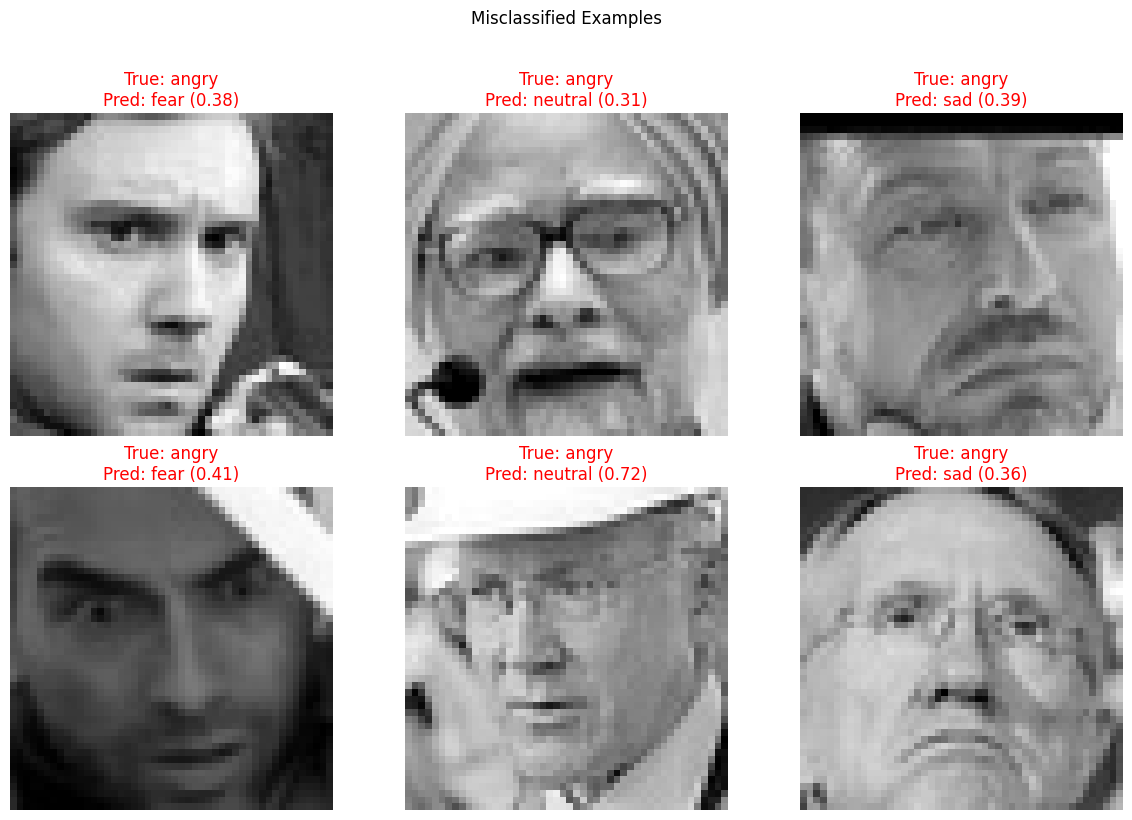

In [ ]:
best_row = comparison_df.sort_values("Test Accuracy", ascending=False).iloc[0]
best_model_name = best_row["Model"]
print("Best model based on test accuracy:", best_model_name)

if best_model_name == "MobileNetV2 Transfer Learning":
    best_model = transfer_model
    best_dataset = transfer_test_ds
else:

    best_model = deeper_model
    best_dataset = test_ds

all_images = []
all_true = []
for images, labels in best_dataset:
    all_images.append(images.numpy())
    all_true.append(labels.numpy())

all_images = np.concatenate(all_images, axis=0)
all_true = np.concatenate(all_true, axis=0)

all_probs = best_model.predict(best_dataset, verbose=0)
all_pred = np.argmax(all_probs, axis=1)

wrong_indices = np.where(all_true != all_pred)[0]
print("Number of misclassified examples:", len(wrong_indices))

plt.figure(figsize=(12, 8))
for plot_i, idx in enumerate(wrong_indices[:6], start=1):
    plt.subplot(2, 3, plot_i)
    img = all_images[idx]

    if img.shape[-1] == 1:
        plt.imshow(np.squeeze(img), cmap="gray")
    else:

        plt.imshow(img.astype("uint8"))

    true_label = class_names[int(all_true[idx])]
    pred_label = class_names[int(all_pred[idx])]
    confidence = np.max(all_probs[idx])

    plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.2f})", color="red")
    plt.axis("off")

plt.suptitle("Misclassified Examples", y=1.02)
plt.tight_layout()
plt.show()


### Code explanation
This cell creates an output directory, saves the trained Keras models, exports the comparison table as a CSV file, and prints the save location.


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/AL ML/Assignment/vision_task_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

baseline_model.save(os.path.join(SAVE_DIR, "baseline_cnn_improved.keras"))
deeper_model.save(os.path.join(SAVE_DIR, "deeper_regularized_cnn.keras"))
transfer_model.save(os.path.join(SAVE_DIR, "mobilenetv3large_pointattention_transfer.keras"))

comparison_df.to_csv(os.path.join(SAVE_DIR, "model_comparison_results.csv"), index=False)

print("Saved models and comparison table to:", SAVE_DIR)


Saved models and comparison table to: /content/drive/MyDrive/AI ML/Assignment/vision_task_outputs
